## 유의한 변수만 남겼을 때 스트레스 예측 성능은 어떻게 달라지는가?

Dacon 스트레스 데이터셋으로 스트레스 지수를 예측하는 회귀 모델을 구축했다.  
모든 변수를 그대로 쓰는 것이 아니라, 통계 검정으로 유의한 변수를 선별하고  
다중공선성을 제거한 뒤 모델링하는 과정을 거쳤다.

**분석 진행 내용**
- 다중공선성 체크 (VIF 검정)
- PCA (누적 분산 85% 기준)
- PCA 변환 데이터로 회귀 모델링
- 범주형 변수: ANOVA, 독립 2표본 검정으로 stress_score와의 유의성 확인
- 유의한 변수들 간 독립성 검정 수행
- 서로 독립인 변수들만 사용하여 최종 모델링
- RandomForest Feature Importance → 상위 변수만 넣고 모델 재학습

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
import os

In [2]:
filepath = 'C:/Users/user/vs_code/data/'
stress_data = os.path.join(filepath, "dacon_basic/stress_data/train.csv")

df = pd.read_csv(stress_data)

In [3]:
df.info() # object, float64, int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   gender                    3000 non-null   object 
 2   age                       3000 non-null   int64  
 3   height                    3000 non-null   float64
 4   weight                    3000 non-null   float64
 5   cholesterol               3000 non-null   float64
 6   systolic_blood_pressure   3000 non-null   int64  
 7   diastolic_blood_pressure  3000 non-null   int64  
 8   glucose                   3000 non-null   float64
 9   bone_density              3000 non-null   float64
 10  activity                  3000 non-null   object 
 11  smoke_status              3000 non-null   object 
 12  medical_history           1711 non-null   object 
 13  family_medical_history    1514 non-null   object 
 14  sleep_pa

In [4]:
df.describe()
# 거의 모든 데이터가 정규분포에 가까움

,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,mean_working,stress_score
count,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,1968.000000,3000.000000
mean,53.06800,168.585687,72.486680,233.910523,146.144333,95.504000,126.467720,0.933367,8.716972,0.482130
std,20.67207,9.351876,13.167222,24.333434,15.845310,9.895283,18.536844,0.444783,1.628944,0.288252
min,17.00000,141.130000,36.320000,148.810000,97.000000,60.000000,70.050000,-0.220000,4.000000,0.000000
25%,35.00000,161.800000,63.035000,216.927500,135.000000,89.000000,113.912500,0.560000,8.000000,0.230000
50%,53.00000,168.115000,71.240000,234.255000,146.000000,95.000000,126.555000,0.940000,9.000000,0.480000
75%,72.00000,175.352500,81.832500,250.377500,158.000000,102.000000,139.180000,1.300000,10.000000,0.730000
max,89.00000,195.280000,120.880000,313.350000,191.000000,124.000000,185.740000,2.000000,16.000000,1.000000


In [5]:
null_df = pd.DataFrame({'count' : df.isna().sum(), 'ratio' : round(df.isna().mean(), 2) })
null_df

,count,ratio
ID,0,0.00
gender,0,0.00
age,0,0.00
height,0,0.00
weight,0,0.00
cholesterol,0,0.00
systolic_blood_pressure,0,0.00
diastolic_blood_pressure,0,0.00
glucose,0,0.00
bone_density,0,0.00


# Null값처리

In [6]:
df['medical_history'].value_counts()

medical_history
high blood pressure    697
heart disease          508
diabetes               506
Name: count, dtype: int64

In [7]:
df['family_medical_history'].value_counts()
# 고혈압
# 심장질환
# 당뇨

# 결측치 처리 아이디어
# None => 0
# 상관관계가 높은 변수로 추정
# 동일 비율 유지 7:5:5

family_medical_history
diabetes               615
high blood pressure    480
heart disease          419
Name: count, dtype: int64

In [8]:
df['edu_level'].value_counts()

edu_level
high school diploma    924
bachelors degree       880
graduate degree        589
Name: count, dtype: int64

In [9]:
df['mean_working'] = df['mean_working'].fillna(0)

In [10]:
df.dropna(subset = ['edu_level'], inplace = True)

In [11]:
df['medical_history'] = df['medical_history'].fillna("None")
df['family_medical_history'] = df['family_medical_history'].fillna("None")

In [12]:
df.reset_index(drop=True, inplace=True)

In [13]:
df.describe()

,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,mean_working,stress_score
count,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000
mean,52.738404,168.698893,72.613030,234.103276,145.959883,95.330130,126.518496,0.939193,5.814041,0.474747
std,20.667642,9.316585,13.143079,23.954518,15.893276,9.907583,18.506687,0.443061,4.309817,0.287964
min,17.000000,141.130000,37.510000,148.810000,99.000000,60.000000,70.050000,-0.220000,0.000000,0.000000
25%,35.000000,162.050000,63.280000,217.380000,135.000000,89.000000,114.050000,0.570000,0.000000,0.220000
50%,52.000000,168.280000,71.340000,234.370000,146.000000,95.000000,126.550000,0.950000,8.000000,0.470000
75%,71.000000,175.350000,82.180000,250.300000,158.000000,102.000000,139.210000,1.310000,9.000000,0.720000
max,89.000000,195.280000,115.340000,313.350000,191.000000,124.000000,184.290000,2.000000,16.000000,1.000000


# 종속변수의 분포

Text(0, 0.5, 'Frequency')

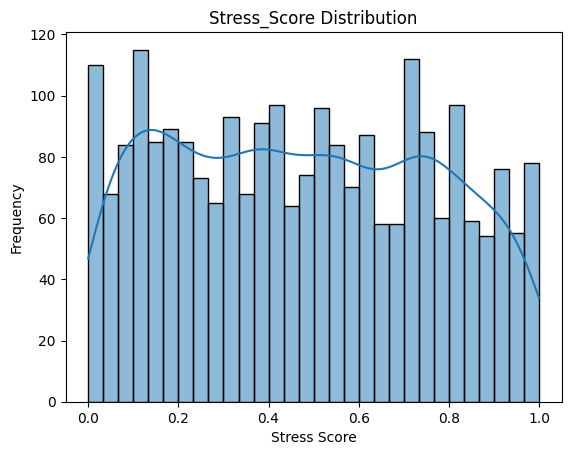

In [14]:
sns.histplot(df['stress_score'], kde=True, bins=30)
plt.title("Stress_Score Distribution")
plt.xlabel("Stress Score")
plt.ylabel("Frequency")

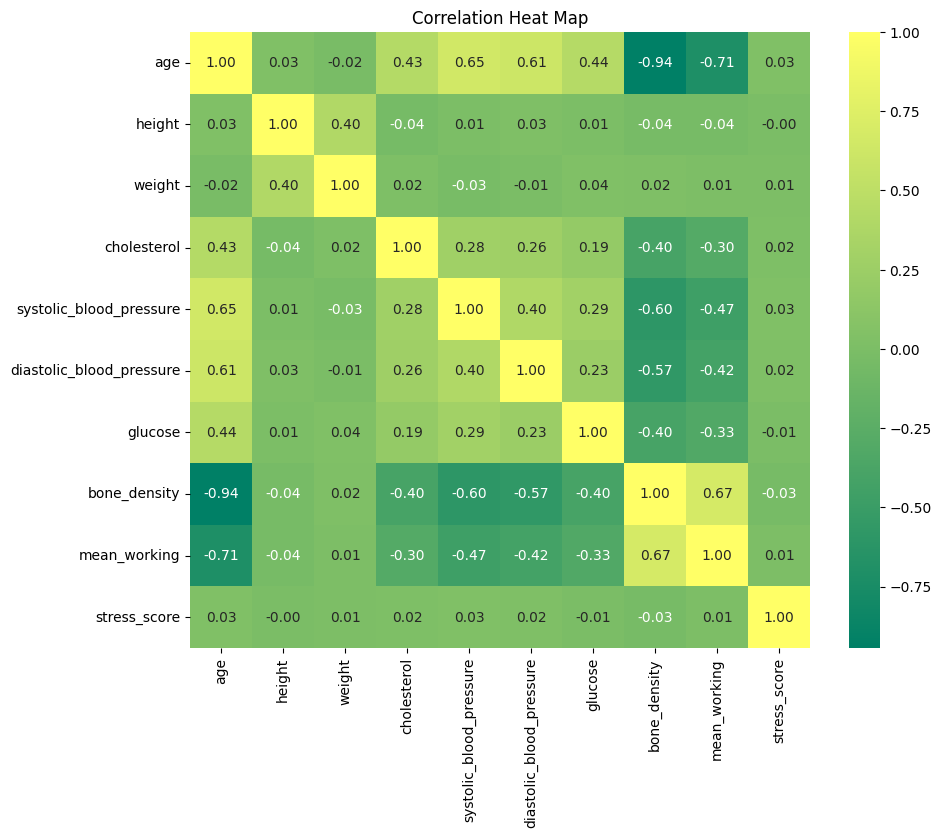

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='summer', fmt='.2f')
plt.title("Correlation Heat Map")
plt.show()

# VIF 검정
- 다중공선성이 높기 때문에 PCA를 진행하기로 결정함

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df.iloc[ :, 1:-1]
# 수치형 컬럼만 추출
vif_data = vif_data.select_dtypes(include='number')


# VIF 계산
vif_df = pd.DataFrame()
vif_df["feature"] = vif_data.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data.values, i)
                 for i in range(vif_data.shape[1])]
vif_df


,feature,VIF
0,age,89.867760
1,height,242.411339
2,weight,37.569851
3,cholesterol,104.217027
4,systolic_blood_pressure,132.841163
5,diastolic_blood_pressure,132.780353
6,glucose,56.488214
7,bone_density,41.382227
8,mean_working,5.542684


# 데이터 전처리


In [44]:
y = df['stress_score']
X = df.drop(labels= ['stress_score', 'ID'], axis=1)

In [18]:
# 원-핫 인코딩
X_encoded = pd.get_dummies(X, drop_first = True)

In [19]:
# 스케일링
# 정규화 과정 :  일반적으로 서로 다른 변수의 크기를 통일하기 위해 크기를 변환.
# 단위차이가 크게 나면 회귀 모델의 경우 값이 작은 컬럼의 값을 무시하게 될 수 있다.

from sklearn.preprocessing import MinMaxScaler
# min을 0으로 max를 1로 => 이상치의 영향이 작아짐!
scaler = MinMaxScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(scaled_df, y, test_size = 0.3, random_state = 42)

In [21]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1675, 24) (718, 24)
(1675,) (718,)


# 모델링

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


rigde = Ridge(alpha=1.0)
rigde.fit(X_train, y_train)
rigde_pred = rigde.predict(X_test)

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

elastic = ElasticNet(alpha = 0.1, l1_ratio  = 0.5)
elastic.fit(X_train, y_train)
elastic_pred = elastic.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)






[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1439
[LightGBM] [Info] Number of data points in the train set: 1675, number of used features: 24
[LightGBM] [Info] Start training from score 0.470490


In [24]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def evaluate_model(name, pred, y_test):
    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print("Model", name, "MAE" , round(mae, 2), "R2" , round(r2, 2))
    # return {"Model": name, "MSE": mse, "R2" : r2}

In [63]:
models  = [('LinearRegression', lr_pred),
           ('Ridge', rigde_pred),
           ('Lasso', lasso_pred),
           ('ElasticNet', elastic_pred),
            ('RandomForestRegressor', rf_pred),
            ('LightGBM', lgbm_pred)]

In [26]:
for m, p in models:
    print(f"----------{m}-----------")
    evaluate_model(m, p, y_test)
    print()

----------LinearRegression-----------
Model LinearRegression MAE 0.25 R2 -0.02

----------Ridge-----------
Model Ridge MAE 0.25 R2 -0.02

----------Lasso-----------
Model Lasso MAE 0.25 R2 -0.0

----------ElasticNet-----------
Model ElasticNet MAE 0.25 R2 -0.0

----------RandomForestRegressor-----------
Model RandomForestRegressor MAE 0.2 R2 0.26

----------LightGBM-----------
Model LightGBM MAE 0.21 R2 0.19



C:\Users\user\AppData\Local\Temp\ipykernel_10372\668487500.py:18: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_10372\668487500.py:18: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_10372\668487500.py:18: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_10372\668487500.py:18: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_10372\668487500.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_10372\668487500.py:18: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s)

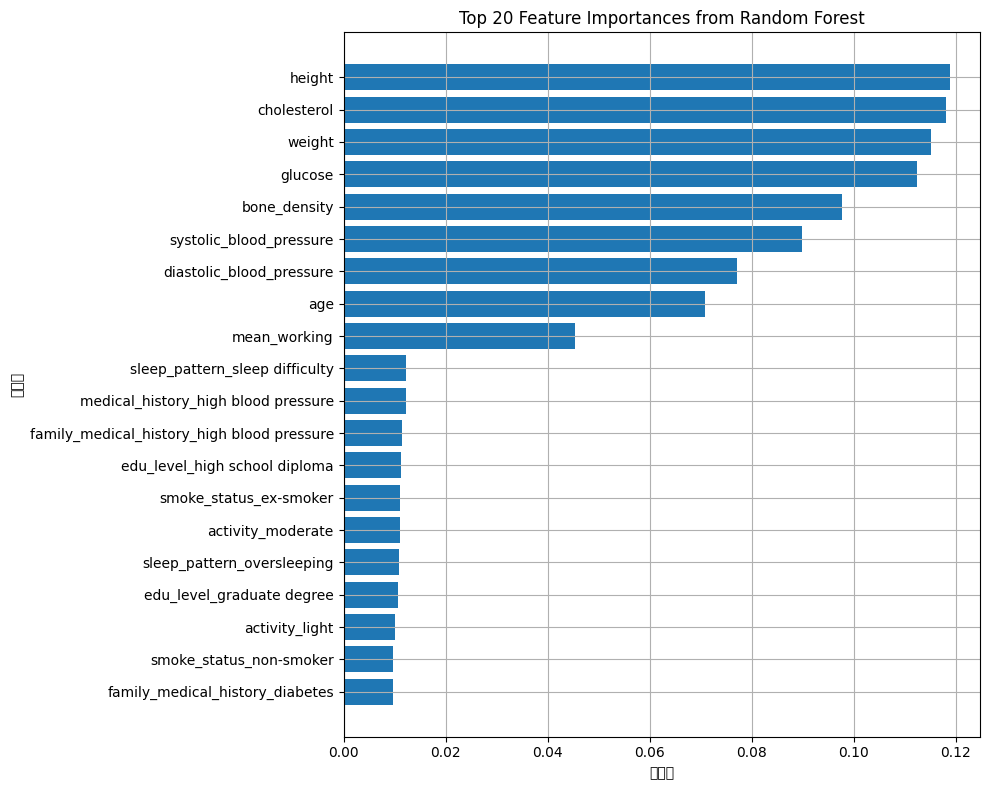

In [27]:
# 중요도 추출
importances = rf.feature_importances_
feature_names = X_train.columns

# 중요도 DataFrame 생성
importance_df = pd.DataFrame({
    '변수명': feature_names,
    '중요도': importances
}).sort_values(by='중요도', ascending=False)

# 상위 20개 변수 시각화
plt.figure(figsize=(10, 8))
plt.barh(importance_df['변수명'][:20][::-1], importance_df['중요도'][:20][::-1])
plt.title('Top 20 Feature Importances from Random Forest')
plt.xlabel('중요도')
plt.ylabel('변수명')
plt.grid(True)
plt.tight_layout()
plt.show()

# 모델 성능 향상
- PCA 수행

In [28]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. PCA 대상 데이터 추출
X = X_train

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 객체를 훈련 데이터로 학습
pca = PCA(n_components=0.85)
X_train_pca = pca.fit_transform(X_train)

# 테스트 데이터는 학습된 PCA 기준으로만 변환
X_test_pca = pca.transform(X_test)

In [29]:
lr = LinearRegression()
lr.fit(X_train_pca, y_train)
lr_pred_pca = lr.predict(X_test_pca)


rigde = Ridge(alpha=1.0)
rigde.fit(X_train_pca, y_train)
rigde_pred_pca = rigde.predict(X_test_pca)

lasso = Lasso(alpha=1.0)
lasso.fit(X_train_pca, y_train)
lasso_pred_pca = lasso.predict(X_test_pca)

elastic = ElasticNet(alpha = 0.1, l1_ratio  = 0.5)
elastic.fit(X_train_pca, y_train)
elastic_pred_pca = elastic.predict(X_test_pca)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_pca, y_train)
rf_pred_pca = rf.predict(X_test_pca)

lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X_train_pca, y_train)
lgbm_pred_pca = lgbm.predict(X_test_pca)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 1675, number of used features: 12
[LightGBM] [Info] Start training from score 0.470490


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [31]:
models  = [('LinearRegression', lr_pred_pca),
           ('Ridge', rigde_pred_pca),
           ('Lasso', lasso_pred_pca),
           ('ElasticNet', elastic_pred_pca),
            ('RandomForestRegressor', rf_pred_pca),
            ('LightGBM', lgbm_pred_pca)]

for m, p in models:
    print(f"----------{m}-----------")
    evaluate_model(m, p, y_test)
    print()

----------LinearRegression-----------
Model LinearRegression MAE 0.25 R2 -0.01

----------Ridge-----------
Model Ridge MAE 0.25 R2 -0.01

----------Lasso-----------
Model Lasso MAE 0.25 R2 -0.0

----------ElasticNet-----------
Model ElasticNet MAE 0.25 R2 -0.0

----------RandomForestRegressor-----------
Model RandomForestRegressor MAE 0.22 R2 0.16

----------LightGBM-----------
Model LightGBM MAE 0.22 R2 0.1



- pca 진행 후 모델링한 성능이 좋지 않기에 범주형 변수들로 데이터를 슬라이싱하여 검정을 진행하기로 함

# 범주형 변수들의 집단별 스트레스 지수 차이에 대한 검정
- ANOVA
- 독립 2표본

In [32]:
df[['medical_history', 'family_medical_history', 'edu_level', 'mean_working']]

,medical_history,family_medical_history,edu_level,mean_working
0,high blood pressure,diabetes,bachelors degree,0.0
1,None,diabetes,graduate degree,0.0
2,None,None,high school diploma,9.0
3,high blood pressure,None,graduate degree,0.0
4,diabetes,diabetes,bachelors degree,0.0
...,...,...,...,...
2388,None,None,graduate degree,8.0
2389,heart disease,high blood pressure,bachelors degree,7.0
2390,high blood pressure,high blood pressure,high school diploma,7.0
2391,None,None,high school diploma,9.0


In [34]:
## 교육 수준에 따른 스트레스 지수 차이

groups = [group['stress_score'] for name, group in df.groupby('edu_level')] # 그룹별 데이터 분리

from scipy.stats import f_oneway
f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

## 귀무가설 채택 : 교육 수준 그룹의 평균 스트레스 지수 차이가 없다.

F-statistic: 0.8546, p-value: 0.4256


In [35]:
## 수면 패턴에 따른 스트레스 지수 차이

groups = [group['stress_score'] for name, group in df.groupby('sleep_pattern')] # 그룹별 데이터 분리

from scipy.stats import f_oneway
f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

## 귀무가설 기각 : 수면 패턴에 따라 스트레스 지수가 차이가 난다.

F-statistic: 3.0950, p-value: 0.0455


In [36]:
## 가족력에 따른 스트레스 지수 차이

groups = [group['stress_score'] for name, group in df.groupby('family_medical_history')] # 그룹별 데이터 분리

from scipy.stats import f_oneway
f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

## 귀무가설 기각 : 가족력에 따라 스트레스 지수가 차이가 난다.

F-statistic: 2.8497, p-value: 0.0361


In [37]:
 ## 만성질환에 따른 스트레스 지수 차이

groups = [group['stress_score'] for name, group in df.groupby('medical_history')] # 그룹별 데이터 분리

from scipy.stats import f_oneway
f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

## 귀무가설 기각 : 만성질환에 따라 스트레스 지수가 차이가 난다.

F-statistic: 3.4407, p-value: 0.0162


In [38]:
 ## 흡연 여부에 따른 스트레스 지수 차이

groups = [group['stress_score'] for name, group in df.groupby('smoke_status')] # 그룹별 데이터 분리

from scipy.stats import f_oneway
f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

## 귀무가설 채택 : 흡연 여부에 따라 스트레스 지수 차이가 없다.

F-statistic: 1.8564, p-value: 0.1565


In [39]:
## 수면 패턴, 가족력, 만성질환 독립성 검정

## 교차표
contingency = pd.crosstab(df['sleep_pattern'], df['family_medical_history'])

# 카이제곱 검정
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}")

Chi2: 3.8588, p-value: 0.6958


In [40]:
from scipy.stats import chi2_contingency

# 수면 패턴 vs 가족력
ct1 = pd.crosstab(df['sleep_pattern'], df['family_medical_history'])
chi2, p, dof, expected = chi2_contingency(ct1)
print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}")
print('---------------------------------------------------------------')
print('')

# 수면 패턴 vs 만성질환
ct2 = pd.crosstab(df['sleep_pattern'], df['medical_history'])
chi2, p, dof, expected = chi2_contingency(ct2)
print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}")
print('---------------------------------------------------------------')
print('')

# 가족력 vs 만성질환
ct3 = pd.crosstab(df['family_medical_history'], df['medical_history'])
chi2, p, dof, expected = chi2_contingency(ct3)
print(f"Chi2: {chi2:.4f}, p-value: {p}")


## -- 결론 : 가족력과 만성질환 간 통계적 연관성이 있음

Chi2: 3.8588, p-value: 0.6958
---------------------------------------------------------------

Chi2: 8.9117, p-value: 0.1786
---------------------------------------------------------------

Chi2: 1015.7821, p-value: 6.811774358914508e-213


# 범주형 변수들만 사용하여 모델링 수행
- family_medical_history / medical_history

/

- medical_history / sleep_pattern

In [41]:
y = df['stress_score']
X = df[['sleep_pattern', 'medical_history']]

In [42]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded

,sleep_pattern_oversleeping,sleep_pattern_sleep difficulty,medical_history_diabetes,medical_history_heart disease,medical_history_high blood pressure
0,False,True,False,False,True
1,False,False,False,False,False
2,False,False,False,False,False
3,True,False,False,False,True
4,False,True,True,False,False
...,...,...,...,...,...
2388,False,True,False,False,False
2389,False,True,False,True,False
2390,True,False,False,False,True
2391,False,False,False,False,False


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

## 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

## 모델 예측
y_pred = model.predict(X_test)

## 평가 지표
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.3f}')
print(f'R²: {r2:.3f}')

MAE: 0.250
R²: -0.009


In [45]:
X = df[['family_medical_history', 'sleep_pattern']]
y = df['stress_score']

In [46]:
df_check_encoded = pd.get_dummies(X, drop_first= True)

In [47]:
X_train, X_test, y_train, y_test = train_test_split (df_check_encoded, y, test_size=0.3, random_state=42)


In [48]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


# 평가 지표
mae = mean_absolute_error(y_test, lr_pred)
r2 = r2_score(y_test, lr_pred)

print(f'MAE: {mae:.3f}')
print(f'R2: {r2:.3f}')

MAE: 0.250
R2: -0.011


# Random Forest Regressor의 feture_imprtance 상위 데이터를 기준으로 학습

In [57]:
X = scaled_df[['height', 'cholesterol', 'weight', 'glucose', 'bone_density', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'age', 'mean_working']]
y = df['stress_score']

In [60]:
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.3, random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rigde = Ridge(alpha=1.0)
rigde.fit(X_train, y_train)
rigde_pred = rigde.predict(X_test)

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

elastic = ElasticNet(alpha = 0.1, l1_ratio  = 0.5)
elastic.fit(X_train, y_train)
elastic_pred = elastic.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1409
[LightGBM] [Info] Number of data points in the train set: 1675, number of used features: 9
[LightGBM] [Info] Start training from score 0.470490


In [64]:
def evaluate_model(name, pred, y_test):
    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print("Model", name, "MAE" , round(mae, 2), "R2" , round(r2, 2))
    # return {"Model": name, "MSE": mse, "R2" : r2}

models  = [('LinearRegression', lr_pred),
           ('Ridge', rigde_pred),
           ('Lasso', lasso_pred),
           ('ElasticNet', elastic_pred),
            ('RandomForestRegressor', rf_pred),
            ('LightGBM', lgbm_pred)]

In [ ]:
for m, p in models:
    print(f"----------{m}-----------")
    evaluate_model(m, p, y_test)
    print()

----------LinearRegression-----------
Model LinearRegression MAE 0.25 R2 -0.01

----------Ridge-----------
Model Ridge MAE 0.25 R2 -0.0

----------Lasso-----------
Model Lasso MAE 0.25 R2 -0.0

----------ElasticNet-----------
Model ElasticNet MAE 0.25 R2 -0.0

----------RandomForestRegressor-----------
Model RandomForestRegressor MAE 0.2 R2 0.26

----------LightGBM-----------
Model LightGBM MAE 0.22 R2 0.17



# 그리드 서치 RF 하이퍼파라미터 튜닝
- rf 모델의 mae가 0.2 이므로 그리드서치를 통해 하이퍼파리미터 튜닝을 진행한다.

In [66]:
from sklearn.model_selection import GridSearchCV

# 기본 모델
rf = RandomForestRegressor(random_state=42)

# 그리드 설정
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='neg_mean_absolute_error',
                           n_jobs=-1, verbose=2)

# 학습
grid_search.fit(X_train, y_train)

# 결과 확인
print("최적 파라미터:", grid_search.best_params_)
print("최적 MAE:", -grid_search.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
최적 파라미터: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
최적 MAE: 0.21359785074626864


# 파생변수 만들기
-bmi 지수

In [73]:
df['BMI'] = df['weight'] / (df['height'] / 100) ** 2
df['pulse_pressure'] = df['systolic_blood_pressure'] - df['diastolic_blood_pressure']


In [86]:
X = df[['BMI', 'pulse_pressure', 'cholesterol', 'glucose', 'bone_density', 'age', 'mean_working']]
y = df['stress_score']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [88]:
X_train, X_test, y_train, y_test = train_test_split (X_scaled, y, test_size=0.3, random_state=42)

In [89]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


rigde = Ridge(alpha=1.0)
rigde.fit(X_train, y_train)
rigde_pred = rigde.predict(X_test)

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

elastic = ElasticNet(alpha = 0.1, l1_ratio  = 0.5)
elastic.fit(X_train, y_train)
elastic_pred = elastic.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1102
[LightGBM] [Info] Number of data points in the train set: 1675, number of used features: 7
[LightGBM] [Info] Start training from score 0.470490


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [90]:
models  = [('LinearRegression', lr_pred),
           ('Ridge', rigde_pred),
           ('Lasso', lasso_pred),
           ('ElasticNet', elastic_pred),
            ('RandomForestRegressor', rf_pred),
            ('LightGBM', lgbm_pred)]

for m, p in models:
    print(f"----------{m}-----------")
    evaluate_model(m, p, y_test)
    print()

----------LinearRegression-----------
Model LinearRegression MAE 0.25 R2 -0.0

----------Ridge-----------
Model Ridge MAE 0.25 R2 -0.0

----------Lasso-----------
Model Lasso MAE 0.25 R2 -0.0

----------ElasticNet-----------
Model ElasticNet MAE 0.25 R2 -0.0

----------RandomForestRegressor-----------
Model RandomForestRegressor MAE 0.21 R2 0.2

----------LightGBM-----------
Model LightGBM MAE 0.23 R2 0.1



In [91]:
# 그리드 설정
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='neg_mean_absolute_error',
                           n_jobs=-1, verbose=2)

# 학습
grid_search.fit(X_train, y_train)

# 결과 확인
print("최적 파라미터:", grid_search.best_params_)
print("최적 MAE:", -grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
최적 파라미터: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
최적 MAE: 0.21703540298507465


# 결론
- 데이터 자체의 설명력이 떨어지는 것 같다.
- height', 'cholesterol', 'weight', 'glucose', 'bone_density', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'age', 'mean_working 컬럼을 사용하여 만든 rf모델의 성능이 MAE 0.2 R2 0.26으로 최선인 것 같다.